# E-Commerce Dataset Analysis
## Exploratory Data Analysis

**Dataset:** E Commerce Dataset.xlsx  
**Date:** February 2026  
**Objective:** Analyze customer behavior, purchase patterns, and retention metrics

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(" Libraries imported successfully!")

 Libraries imported successfully!


## 2. Load Dataset

In [2]:
# Inspect the Excel file structure
xl_file = pd.ExcelFile('E Commerce Dataset.xlsx')
print(f" Sheet names in the workbook: {xl_file.sheet_names}\n")

# Load the actual E-Commerce data from the 'E Comm' sheet
print("=" * 80)
print("Loading E-Commerce Data...")
print("=" * 80)

df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')

print(f" Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Display first few rows
print("First 5 rows of the dataset:")
df.head()

 Sheet names in the workbook: ['Data Dict', 'E Comm']

Loading E-Commerce Data...
 Dataset loaded successfully!
Shape: 5,630 rows × 20 columns

First 5 rows of the dataset:
 Dataset loaded successfully!
Shape: 5,630 rows × 20 columns

First 5 rows of the dataset:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.00,Mobile Phone,3,6.00,Debit Card,Female,3.00,3,Laptop & Accessory,2,Single,9,1,11.00,1.00,1.00,5.00,159.93
1,50002,1,NaN,Phone,1,8.00,UPI,Male,3.00,4,Mobile,3,Single,7,1,15.00,0.00,1.00,0.00,120.90
2,50003,1,NaN,Phone,1,30.00,Debit Card,Male,2.00,4,Mobile,3,Single,6,1,14.00,0.00,1.00,3.00,120.28
3,50004,1,0.00,Phone,3,15.00,Debit Card,Male,2.00,4,Laptop & Accessory,5,Single,8,0,23.00,0.00,1.00,3.00,134.07
4,50005,1,0.00,Phone,1,12.00,CC,Male,NaN,3,Mobile,5,Single,3,0,11.00,1.00,1.00,3.00,129.60


## 3. Initial Data Exploration

In [3]:
# Dataset information
print("="*80)
print("DATASET INFORMATION")
print("="*80)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13

In [4]:
# Statistical summary
print("="*80)
print("STATISTICAL SUMMARY")
print("="*80)
df.describe(include='all').T

STATISTICAL SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,"5,630.00",NaN,NaN,NaN,"52,815.50","1,625.39","50,001.00","51,408.25","52,815.50","54,222.75","55,630.00"
Churn,"5,630.00",NaN,NaN,NaN,0.17,0.37,0.00,0.00,0.00,0.00,1.00
Tenure,"5,366.00",NaN,NaN,NaN,10.19,8.56,0.00,2.00,9.00,16.00,61.00
PreferredLoginDevice,5630,3,Mobile Phone,2765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,"5,630.00",NaN,NaN,NaN,1.65,0.92,1.00,1.00,1.00,3.00,3.00
WarehouseToHome,"5,379.00",NaN,NaN,NaN,15.64,8.53,5.00,9.00,14.00,20.00,127.00
PreferredPaymentMode,5630,7,Debit Card,2314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5630,2,Male,3384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HourSpendOnApp,"5,375.00",NaN,NaN,NaN,2.93,0.72,0.00,2.00,3.00,3.00,5.00
NumberOfDeviceRegistered,"5,630.00",NaN,NaN,NaN,3.69,1.02,1.00,3.00,4.00,4.00,6.00


In [5]:
# Check for missing values
print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percentage', ascending=False)

print(missing_data[missing_data['Missing_Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum():,}")
print(f"Data completeness: {(1 - df.isnull().sum().sum()/(df.shape[0]*df.shape[1]))*100:.2f}%")

MISSING VALUES ANALYSIS
                                                  Column  Missing_Count  \
DaySinceLastOrder                      DaySinceLastOrder            307   
OrderAmountHikeFromlastYear  OrderAmountHikeFromlastYear            265   
Tenure                                            Tenure            264   
OrderCount                                    OrderCount            258   
CouponUsed                                    CouponUsed            256   
HourSpendOnApp                            HourSpendOnApp            255   
WarehouseToHome                          WarehouseToHome            251   

                             Missing_Percentage  
DaySinceLastOrder                          5.45  
OrderAmountHikeFromlastYear                4.71  
Tenure                                     4.69  
OrderCount                                 4.58  
CouponUsed                                 4.55  
HourSpendOnApp                             4.53  
WarehouseToHome          

In [6]:
# Check data types and unique values
print("="*80)
print("COLUMN DETAILS")
print("="*80)

for col in df.columns:
    print(f"\n{col}:")
    print(f"  - Data Type: {df[col].dtype}")
    print(f"  - Unique Values: {df[col].nunique():,}")
    print(f"  - Missing: {df[col].isnull().sum():,} ({df[col].isnull().sum()/len(df)*100:.2f}%)")
    
    if df[col].nunique() < 20 and df[col].dtype == 'object':
        print(f"  - Sample Values: {df[col].unique()[:5].tolist()}")

COLUMN DETAILS

CustomerID:
  - Data Type: int64
  - Unique Values: 5,630
  - Missing: 0 (0.00%)

Churn:
  - Data Type: int64
  - Unique Values: 2
  - Missing: 0 (0.00%)

Tenure:
  - Data Type: float64
  - Unique Values: 36
  - Missing: 264 (4.69%)

PreferredLoginDevice:
  - Data Type: object
  - Unique Values: 3
  - Missing: 0 (0.00%)
  - Sample Values: ['Mobile Phone', 'Phone', 'Computer']

CityTier:
  - Data Type: int64
  - Unique Values: 3
  - Missing: 0 (0.00%)

WarehouseToHome:
  - Data Type: float64
  - Unique Values: 34
  - Missing: 251 (4.46%)

PreferredPaymentMode:
  - Data Type: object
  - Unique Values: 7
  - Missing: 0 (0.00%)


  - Sample Values: ['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet']

Gender:
  - Data Type: object
  - Unique Values: 2
  - Missing: 0 (0.00%)
  - Sample Values: ['Female', 'Male']

HourSpendOnApp:
  - Data Type: float64
  - Unique Values: 6
  - Missing: 255 (4.53%)

NumberOfDeviceRegistered:
  - Data Type: int64
  - Unique Values: 6
  - Missing: 0 (0.00%)

PreferedOrderCat:
  - Data Type: object
  - Unique Values: 6
  - Missing: 0 (0.00%)
  - Sample Values: ['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others', 'Fashion']

SatisfactionScore:
  - Data Type: int64
  - Unique Values: 5
  - Missing: 0 (0.00%)

MaritalStatus:
  - Data Type: object
  - Unique Values: 3
  - Missing: 0 (0.00%)
  - Sample Values: ['Single', 'Divorced', 'Married']

NumberOfAddress:
  - Data Type: int64
  - Unique Values: 15
  - Missing: 0 (0.00%)

Complain:
  - Data Type: int64
  - Unique Values: 2
  - Missing: 0 (0.00%)

OrderAmountHikeFromlastYear:
  - Data Type: float64
  - Unique Values: 16
 

## 4. Data Cleaning & Preprocessing

In [7]:
# Identify date columns and convert them
date_columns = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]

print("Converting date columns...")
for col in date_columns:
    try:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f" {col} converted to datetime")
    except:
        print(f" Could not convert {col}")

print(f"\nDate columns identified: {date_columns}")

Converting date columns...

Date columns identified: []


In [8]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")

if duplicates > 0:
    print("\nSample duplicate rows:")
    print(df[df.duplicated(keep=False)].head())

Duplicate rows: 0 (0.00%)


## 5. Univariate Analysis

NUMERICAL COLUMNS ANALYSIS
Numerical columns: ['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']



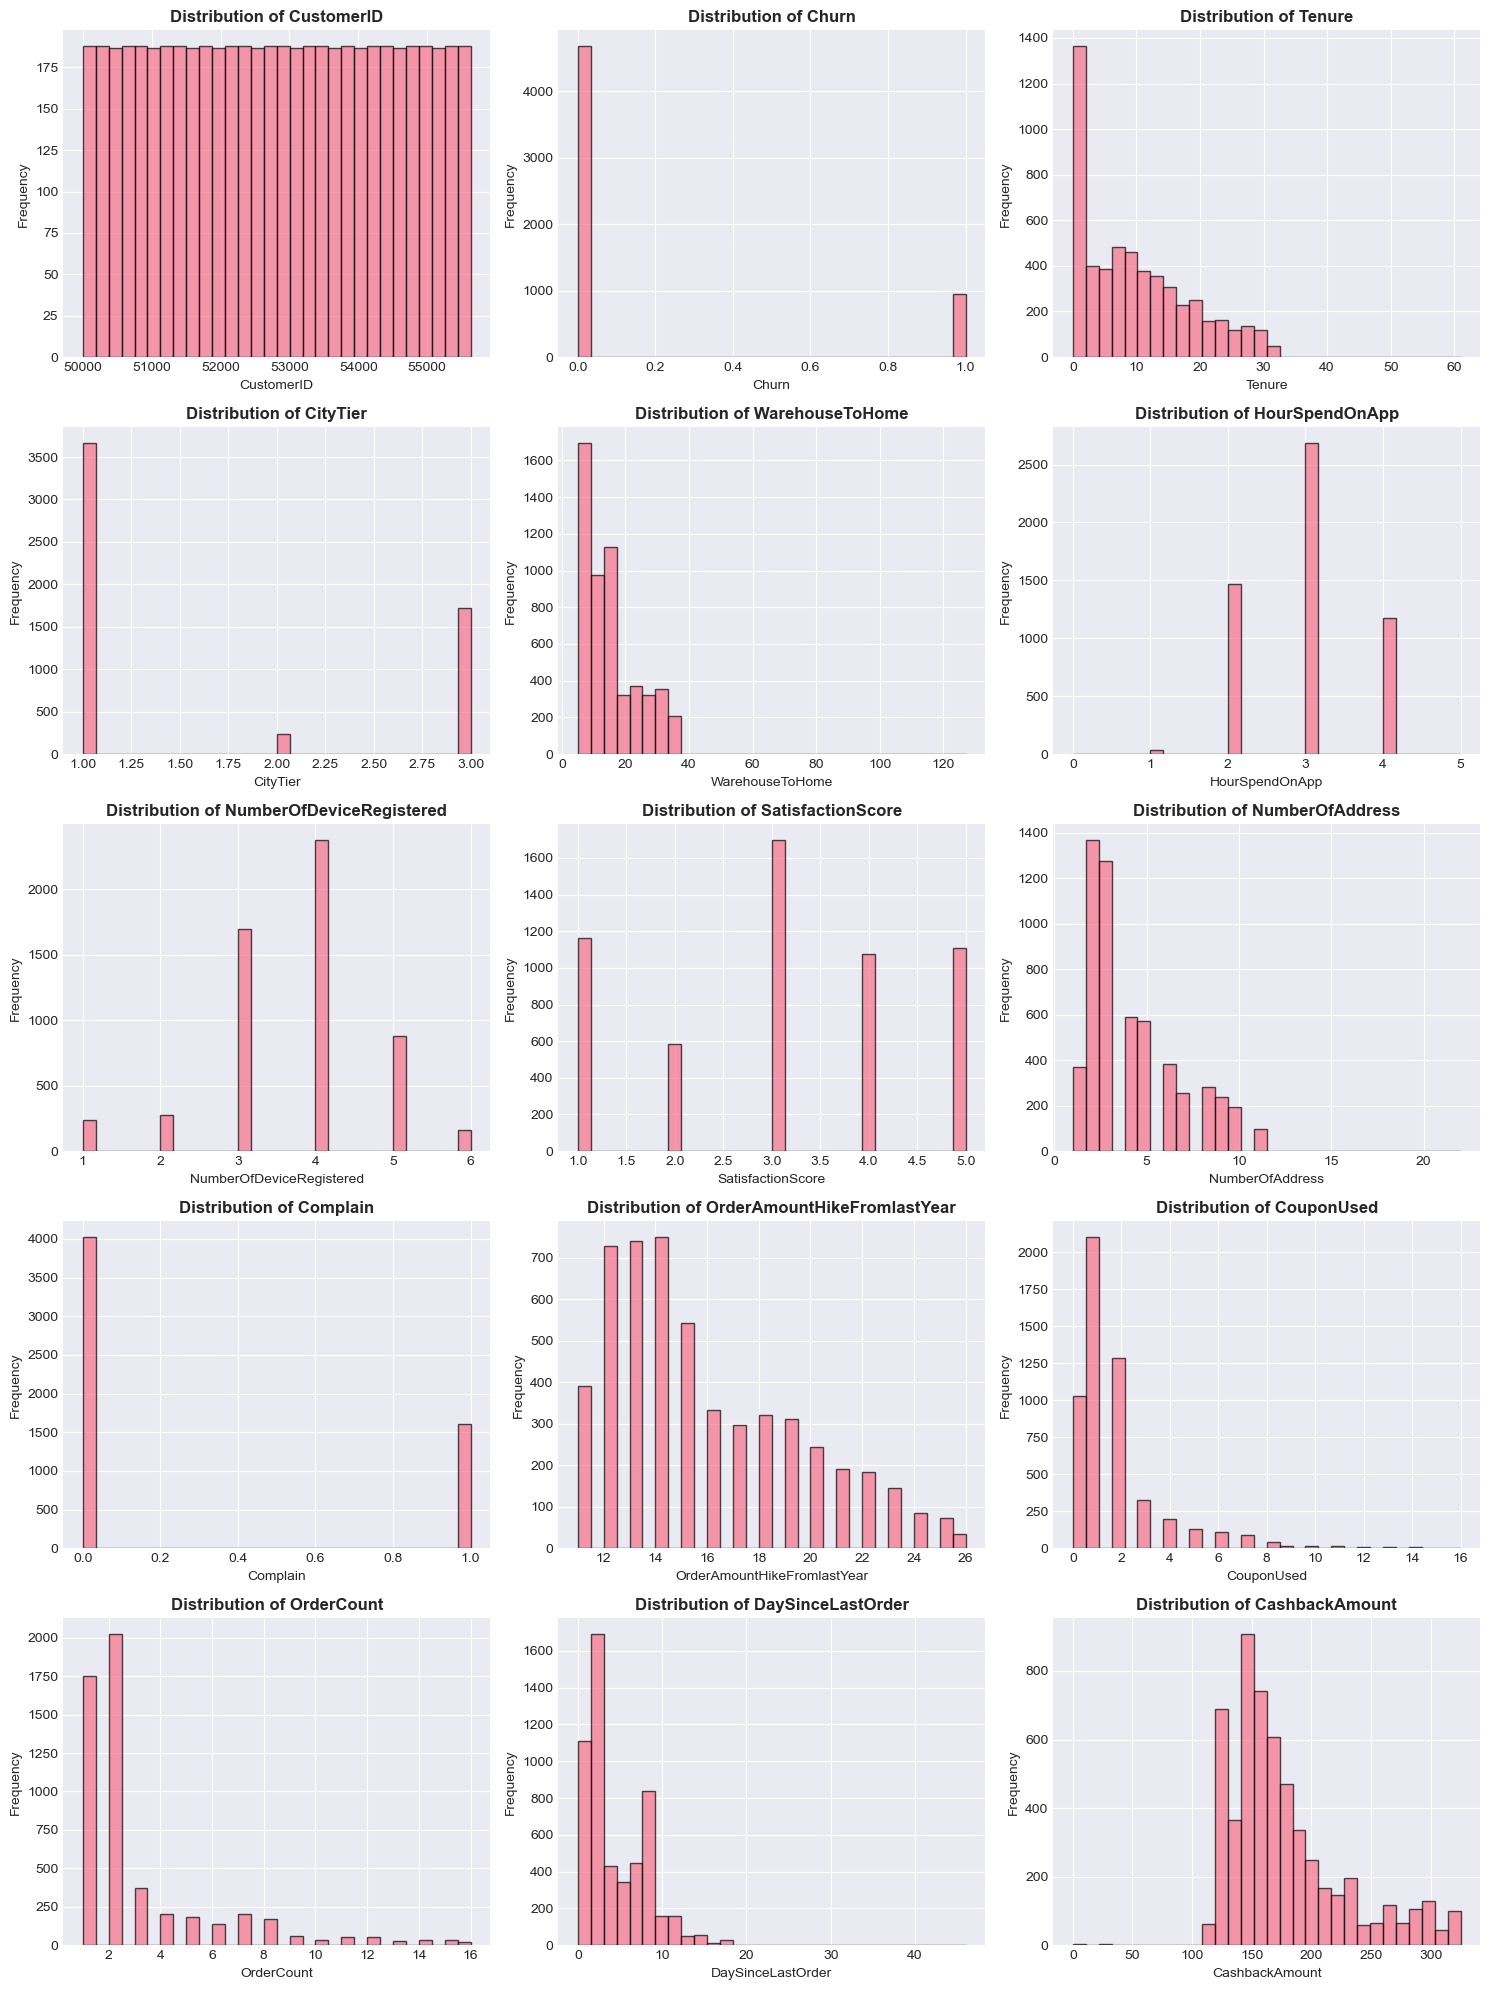

In [9]:
# Analyze numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("="*80)
print("NUMERICAL COLUMNS ANALYSIS")
print("="*80)
print(f"Numerical columns: {numerical_cols}\n")

if len(numerical_cols) > 0:
    # Plot distributions
    n_cols = min(3, len(numerical_cols))
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        if idx < len(axes):
            df[col].hist(bins=30, ax=axes[idx], edgecolor='black', alpha=0.7)
            axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frequency')
    
    # Hide extra subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

In [10]:
# Analyze categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("="*80)
print("CATEGORICAL COLUMNS ANALYSIS")
print("="*80)
print(f"Categorical columns: {categorical_cols}\n")

for col in categorical_cols:
    if df[col].nunique() < 50:  # Only show for columns with fewer categories
        print(f"\n{col} - Value Counts:")
        print(df[col].value_counts().head(10))
        print(f"Unique values: {df[col].nunique()}")

CATEGORICAL COLUMNS ANALYSIS
Categorical columns: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


PreferredLoginDevice - Value Counts:
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
Unique values: 3

PreferredPaymentMode - Value Counts:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
Unique values: 7

Gender - Value Counts:
Gender
Male      3384
Female    2246
Name: count, dtype: int64
Unique values: 2

PreferedOrderCat - Value Counts:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
Unique values: 6

MaritalStatus - Value Counts:
MaritalStatus
Marrie

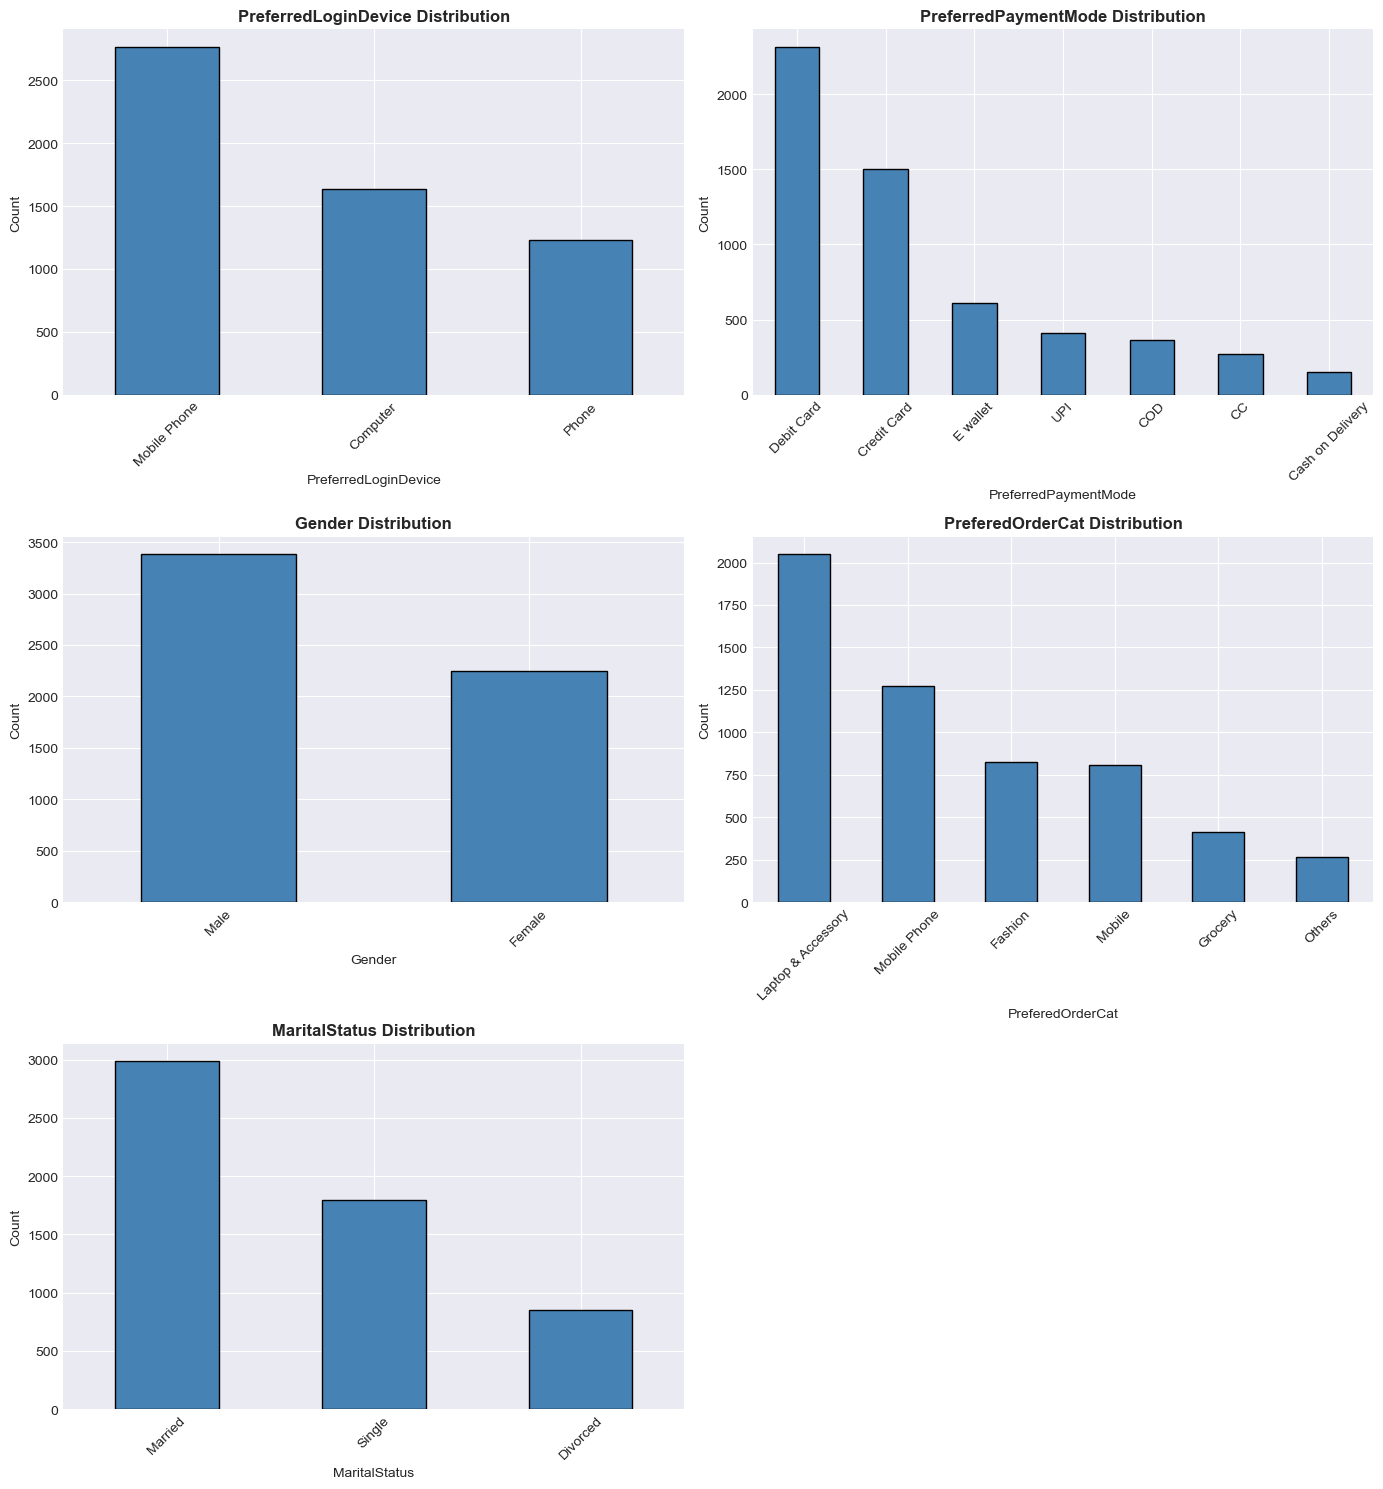

In [11]:
# Visualize top categorical variables
categorical_to_plot = [col for col in categorical_cols if df[col].nunique() < 15]

if len(categorical_to_plot) > 0:
    n_cols = min(2, len(categorical_to_plot))
    n_rows = (len(categorical_to_plot) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    axes = axes.flatten() if len(categorical_to_plot) > 1 else [axes]
    
    for idx, col in enumerate(categorical_to_plot):
        if idx < len(axes):
            value_counts = df[col].value_counts().head(10)
            value_counts.plot(kind='bar', ax=axes[idx], color='steelblue', edgecolor='black')
            axes[idx].set_title(f'{col} Distribution', fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Count')
            axes[idx].tick_params(axis='x', rotation=45)
    
    # Hide extra subplots
    for idx in range(len(categorical_to_plot), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

## 6. Bivariate Analysis

CORRELATION ANALYSIS


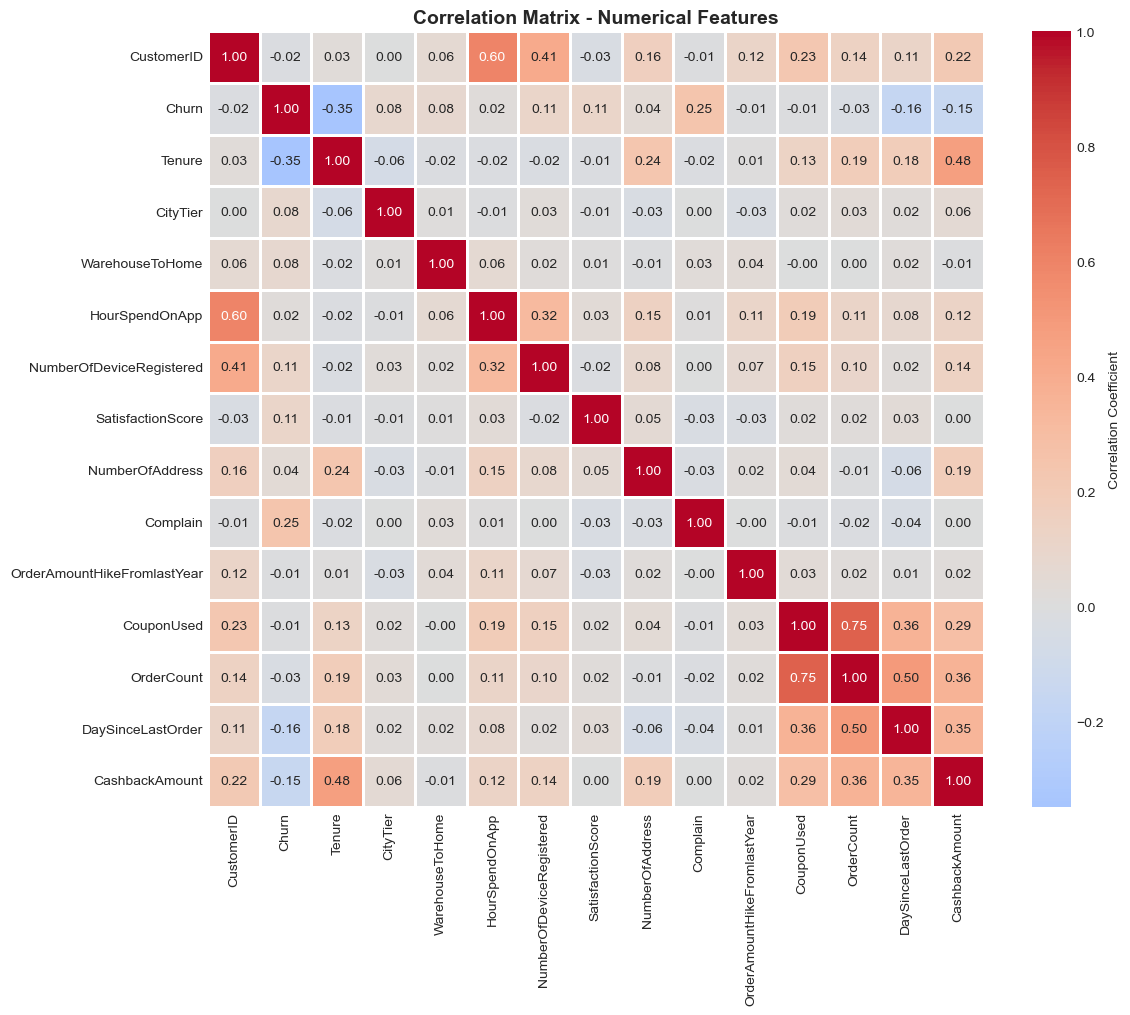


Strong Correlations (|r| > 0.5):
  CustomerID ↔ HourSpendOnApp: 0.598
  CouponUsed ↔ OrderCount: 0.745


In [12]:
# Correlation matrix for numerical variables
if len(numerical_cols) > 1:
    print("="*80)
    print("CORRELATION ANALYSIS")
    print("="*80)
    
    correlation_matrix = df[numerical_cols].corr()
    
    # Plot correlation heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, 
                annot=True, 
                fmt='.2f', 
                cmap='coolwarm', 
                center=0,
                square=True,
                linewidths=1,
                cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print strong correlations
    print("\nStrong Correlations (|r| > 0.5):")
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.5:
                print(f"  {correlation_matrix.columns[i]} ↔ {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

## 7. Customer Analysis (if customer ID exists)

 Customer ID column identified: CustomerID

Total unique customers: 5,630
Total transactions: 5,630
Average transactions per customer: 1.00


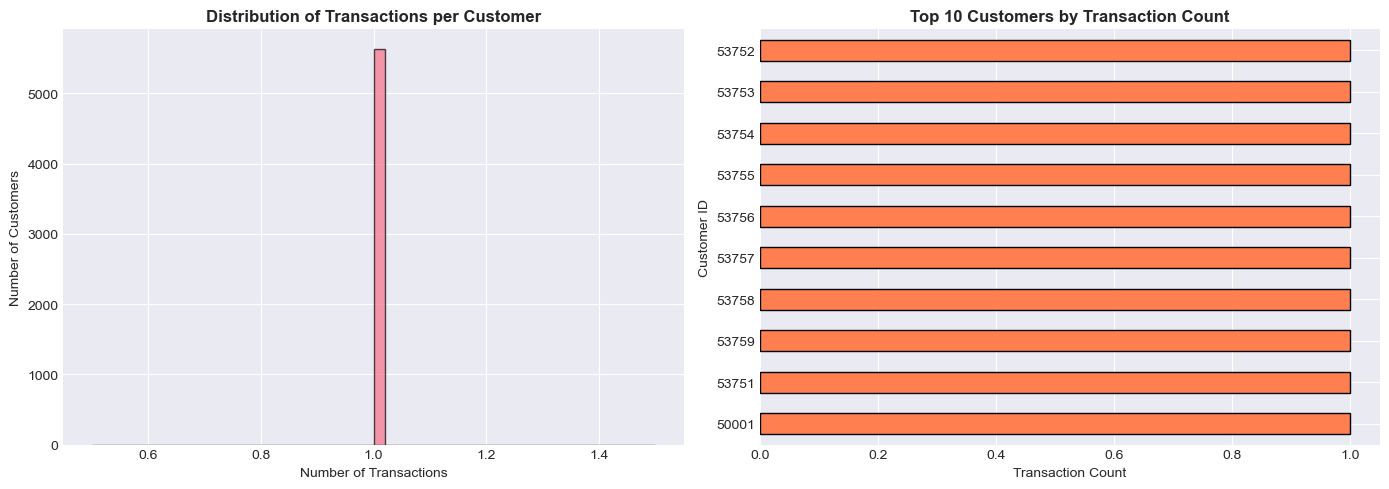

In [13]:
# Try to identify customer ID column
customer_col = None
possible_customer_cols = ['customer_id', 'customerid', 'cust_id', 'user_id', 'userid', 'member_id', 'memberid']

for col in df.columns:
    if col.lower() in possible_customer_cols:
        customer_col = col
        break

if customer_col:
    print(f" Customer ID column identified: {customer_col}")
    print(f"\nTotal unique customers: {df[customer_col].nunique():,}")
    print(f"Total transactions: {len(df):,}")
    print(f"Average transactions per customer: {len(df)/df[customer_col].nunique():.2f}")
    
    # Customer frequency distribution
    customer_freq = df[customer_col].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution of transactions per customer
    customer_freq.hist(bins=50, ax=axes[0], edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribution of Transactions per Customer', fontweight='bold')
    axes[0].set_xlabel('Number of Transactions')
    axes[0].set_ylabel('Number of Customers')
    
    # Top customers
    customer_freq.head(10).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('Top 10 Customers by Transaction Count', fontweight='bold')
    axes[1].set_xlabel('Transaction Count')
    axes[1].set_ylabel('Customer ID')
    
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ No customer ID column detected")
    print(f"Available columns: {df.columns.tolist()}")

## 8. Temporal Analysis (if date columns exist)

In [14]:
# Analyze temporal patterns
if len(date_columns) > 0:
    for date_col in date_columns:
        if df[date_col].dtype == 'datetime64[ns]':
            print(f"\n{'='*80}")
            print(f"TEMPORAL ANALYSIS - {date_col}")
            print(f"{'='*80}")
            
            # Date range
            print(f"Date range: {df[date_col].min()} to {df[date_col].max()}")
            print(f"Total days: {(df[date_col].max() - df[date_col].min()).days} days")
            
            # Extract time features
            df[f'{date_col}_year'] = df[date_col].dt.year
            df[f'{date_col}_month'] = df[date_col].dt.month
            df[f'{date_col}_day'] = df[date_col].dt.day
            df[f'{date_col}_dayofweek'] = df[date_col].dt.dayofweek
            df[f'{date_col}_hour'] = df[date_col].dt.hour
            
            # Plot trends
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            # Trend over time
            df.groupby(df[date_col].dt.date).size().plot(ax=axes[0,0], color='steelblue')
            axes[0,0].set_title(f'Daily Transactions - {date_col}', fontweight='bold')
            axes[0,0].set_xlabel('Date')
            axes[0,0].set_ylabel('Transaction Count')
            axes[0,0].tick_params(axis='x', rotation=45)
            
            # By month
            df[f'{date_col}_month'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='coral', edgecolor='black')
            axes[0,1].set_title('Transactions by Month', fontweight='bold')
            axes[0,1].set_xlabel('Month')
            axes[0,1].set_ylabel('Count')
            
            # By day of week
            day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
            day_counts = df[f'{date_col}_dayofweek'].value_counts().sort_index()
            day_counts.index = [day_names[i] for i in day_counts.index]
            day_counts.plot(kind='bar', ax=axes[1,0], color='lightgreen', edgecolor='black')
            axes[1,0].set_title('Transactions by Day of Week', fontweight='bold')
            axes[1,0].set_xlabel('Day')
            axes[1,0].set_ylabel('Count')
            
            # By hour (if available)
            if df[f'{date_col}_hour'].notna().sum() > 0:
                df[f'{date_col}_hour'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='plum', edgecolor='black')
                axes[1,1].set_title('Transactions by Hour', fontweight='bold')
                axes[1,1].set_xlabel('Hour')
                axes[1,1].set_ylabel('Count')
            else:
                axes[1,1].text(0.5, 0.5, 'No hourly data available', 
                              ha='center', va='center', transform=axes[1,1].transAxes)
                axes[1,1].axis('off')
            
            plt.tight_layout()
            plt.show()
else:
    print(" No date columns detected for temporal analysis")

 No date columns detected for temporal analysis


## 9. Outlier Detection

OUTLIER DETECTION (IQR Method)
                         Column  Outlier_Count  Outlier_Percentage  \
1                         Churn            948               16.84   
12                   OrderCount            703               12.49   
11                   CouponUsed            629               11.17   
14               CashbackAmount            438                7.78   
6      NumberOfDeviceRegistered            397                7.05   
13            DaySinceLastOrder             62                1.10   
10  OrderAmountHikeFromlastYear             33                0.59   
5                HourSpendOnApp              6                0.11   
2                        Tenure              4                0.07   
8               NumberOfAddress              4                0.07   
4               WarehouseToHome              2                0.04   
0                    CustomerID              0                0.00   
3                      CityTier              0             

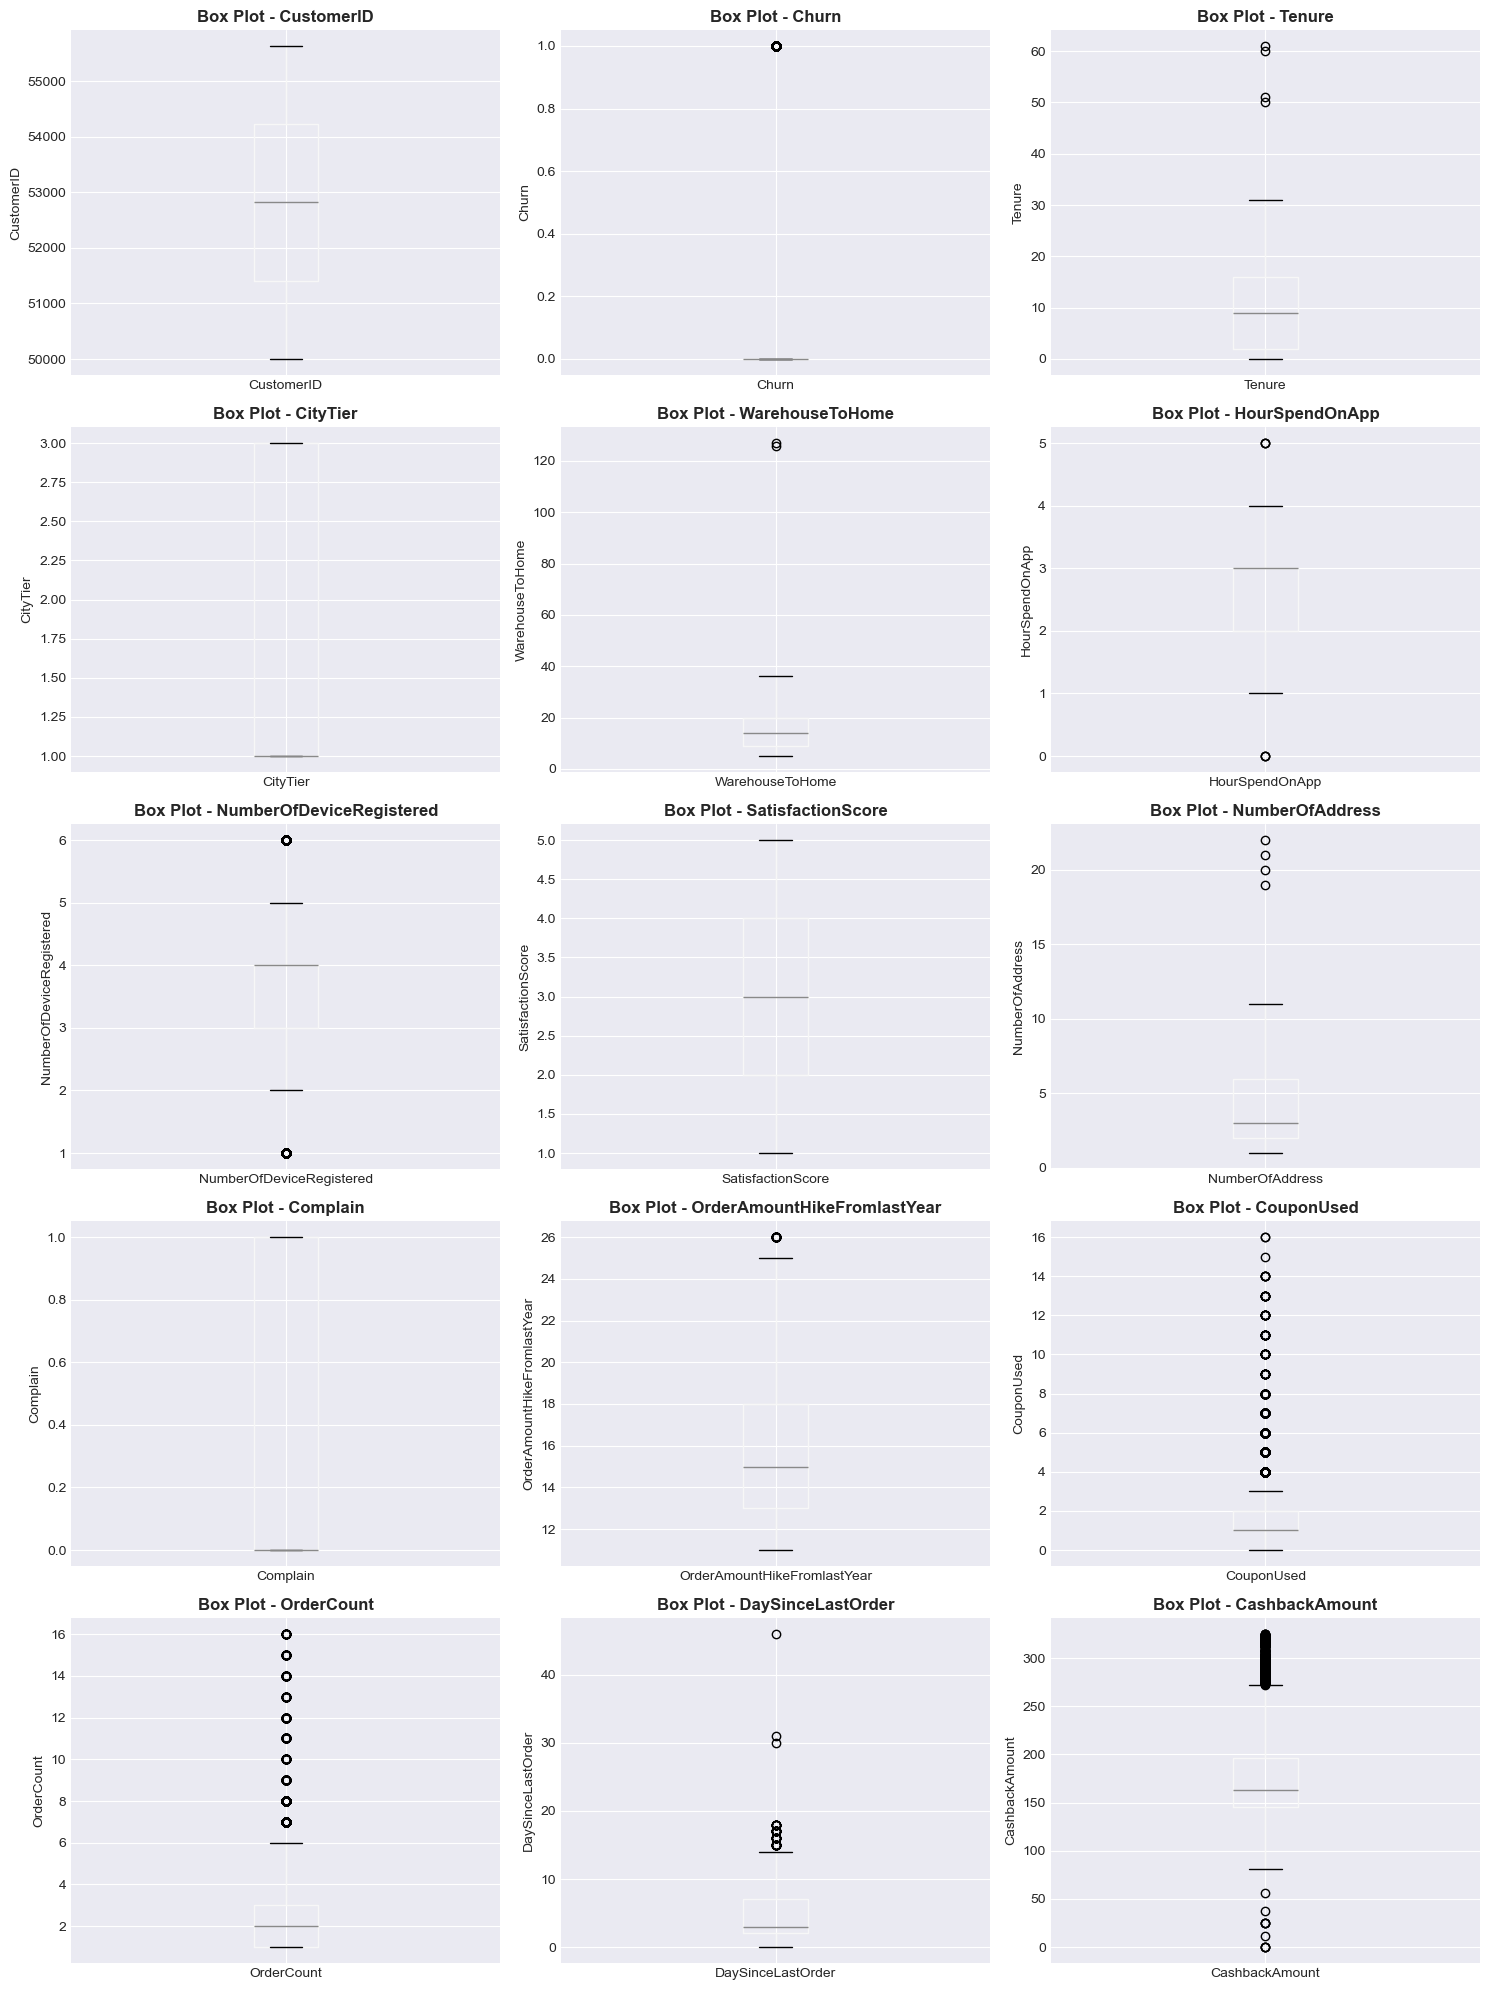

In [15]:
# Detect outliers using IQR method
if len(numerical_cols) > 0:
    print("="*80)
    print("OUTLIER DETECTION (IQR Method)")
    print("="*80)
    
    outlier_summary = []
    
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(df)) * 100
        
        outlier_summary.append({
            'Column': col,
            'Outlier_Count': outlier_count,
            'Outlier_Percentage': outlier_pct,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })
    
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Percentage', ascending=False)
    print(outlier_df)
    
    # Box plots for outlier visualization
    if len(numerical_cols) > 0:
        n_cols = min(3, len(numerical_cols))
        n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
        axes = axes.flatten() if len(numerical_cols) > 1 else [axes]
        
        for idx, col in enumerate(numerical_cols):
            if idx < len(axes):
                df.boxplot(column=col, ax=axes[idx])
                axes[idx].set_title(f'Box Plot - {col}', fontweight='bold')
                axes[idx].set_ylabel(col)
        
        # Hide extra subplots
        for idx in range(len(numerical_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()

## 10. Key Insights & Summary

In [16]:
print("="*80)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*80)

print(f"\n DATASET OVERVIEW:")
print(f"  • Total Records: {len(df):,}")
print(f"  • Total Features: {df.shape[1]}")
print(f"  • Numerical Features: {len(numerical_cols)}")
print(f"  • Categorical Features: {len(categorical_cols)}")
print(f"  • Date Features: {len(date_columns)}")

if customer_col:
    print(f"\n CUSTOMER METRICS:")
    print(f"  • Unique Customers: {df[customer_col].nunique():,}")
    print(f"  • Avg Transactions per Customer: {len(df)/df[customer_col].nunique():.2f}")

print(f"\n DATA QUALITY:")
total_missing = df.isnull().sum().sum()
completeness = (1 - total_missing/(df.shape[0]*df.shape[1]))*100
print(f"  • Missing Values: {total_missing:,}")
print(f"  • Data Completeness: {completeness:.2f}%")
print(f"  • Duplicate Rows: {df.duplicated().sum():,}")

if len(numerical_cols) > 0:
    print(f"\n NUMERICAL FEATURES:")
    for col in numerical_cols[:5]:  # Show first 5
        print(f"  • {col}:")
        print(f"      - Mean: {df[col].mean():.2f}")
        print(f"      - Median: {df[col].median():.2f}")
        print(f"      - Std Dev: {df[col].std():.2f}")

print(f"\n EDA COMPLETED SUCCESSFULLY!")
print(f"\nNext steps:")
print(f"  1. Feature engineering based on insights")
print(f"  2. Handle missing values and outliers")
print(f"  3. Prepare data for modeling")
print(f"  4. Build predictive models")

EXPLORATORY DATA ANALYSIS SUMMARY

 DATASET OVERVIEW:
  • Total Records: 5,630
  • Total Features: 20
  • Numerical Features: 15
  • Categorical Features: 5
  • Date Features: 0

 CUSTOMER METRICS:
  • Unique Customers: 5,630
  • Avg Transactions per Customer: 1.00

 DATA QUALITY:
  • Missing Values: 1,856
  • Data Completeness: 98.35%
  • Duplicate Rows: 0

 NUMERICAL FEATURES:
  • CustomerID:
      - Mean: 52815.50
      - Median: 52815.50
      - Std Dev: 1625.39
  • Churn:
      - Mean: 0.17
      - Median: 0.00
      - Std Dev: 0.37
  • Tenure:
      - Mean: 10.19
      - Median: 9.00
      - Std Dev: 8.56
  • CityTier:
      - Mean: 1.65
      - Median: 1.00
      - Std Dev: 0.92
  • WarehouseToHome:
      - Mean: 15.64
      - Median: 14.00
      - Std Dev: 8.53

 EDA COMPLETED SUCCESSFULLY!

Next steps:
  1. Feature engineering based on insights
  2. Handle missing values and outliers
  3. Prepare data for modeling
  4. Build predictive models


## 12. Feature Engineering for Machine Learning

Creating advanced features to improve model performance and capture complex patterns in customer behavior.

In [17]:
# Create a copy for feature engineering
df_ml = df.copy()

print("="*80)
print("FEATURE ENGINEERING - PART 1: TENURE & LIFECYCLE")
print("="*80)

# 1. TENURE-BASED FEATURES
# Fill missing tenure with median
df_ml['Tenure'].fillna(df_ml['Tenure'].median(), inplace=True)

# Tenure segments
df_ml['Tenure_Segment'] = pd.cut(df_ml['Tenure'], 
                                  bins=[-1, 3, 6, 12, 24, 100],
                                  labels=['New (0-3m)', 'Growing (3-6m)', 'Established (6-12m)', 
                                         'Loyal (12-24m)', 'Champion (24m+)'])

# Is new customer (first 3 months)
df_ml['Is_New_Customer'] = (df_ml['Tenure'] <= 3).astype(int)

# Is loyal customer (>12 months)
df_ml['Is_Loyal_Customer'] = (df_ml['Tenure'] > 12).astype(int)

# Tenure in years
df_ml['Tenure_Years'] = df_ml['Tenure'] / 12

print(f" Tenure features created:")
print(f"   - Tenure_Segment (5 categories)")
print(f"   - Is_New_Customer (binary)")
print(f"   - Is_Loyal_Customer (binary)")
print(f"   - Tenure_Years (continuous)")
print(f"\nTenure Segment Distribution:")
print(df_ml['Tenure_Segment'].value_counts().sort_index())

FEATURE ENGINEERING - PART 1: TENURE & LIFECYCLE
 Tenure features created:
   - Tenure_Segment (5 categories)
   - Is_New_Customer (binary)
   - Is_Loyal_Customer (binary)
   - Tenure_Years (continuous)

Tenure Segment Distribution:
Tenure_Segment
New (0-3m)             1560
Growing (3-6m)          590
Established (6-12m)    1584
Loyal (12-24m)         1467
Champion (24m+)         429
Name: count, dtype: int64


In [18]:
print("\n" + "="*80)
print("FEATURE ENGINEERING - PART 2: ENGAGEMENT & ACTIVITY")
print("="*80)

# 2. ENGAGEMENT FEATURES
# Fill missing HourSpendOnApp
df_ml['HourSpendOnApp'].fillna(df_ml['HourSpendOnApp'].median(), inplace=True)

# Engagement score (normalized combination of app usage and order activity)
df_ml['Engagement_Score'] = (
    (df_ml['HourSpendOnApp'] / df_ml['HourSpendOnApp'].max() * 0.4) +
    (df_ml['OrderCount'] / df_ml['OrderCount'].max() * 0.3) +
    ((df_ml['DaySinceLastOrder'].max() - df_ml['DaySinceLastOrder']) / df_ml['DaySinceLastOrder'].max() * 0.3)
)

# App usage categories
df_ml['App_Usage_Level'] = pd.cut(df_ml['HourSpendOnApp'],
                                   bins=[-1, 1, 2, 3, 100],
                                   labels=['Low', 'Medium', 'High', 'Very High'])

# Is highly engaged (top 25% engagement score)
engagement_threshold = df_ml['Engagement_Score'].quantile(0.75)
df_ml['Is_Highly_Engaged'] = (df_ml['Engagement_Score'] >= engagement_threshold).astype(int)

# Device engagement (more devices = more engaged)
df_ml['Is_Multi_Device_User'] = (df_ml['NumberOfDeviceRegistered'] >= 4).astype(int)

print(f" Engagement features created:")
print(f"   - Engagement_Score (0-1 scale)")
print(f"   - App_Usage_Level (4 categories)")
print(f"   - Is_Highly_Engaged (binary)")
print(f"   - Is_Multi_Device_User (binary)")
print(f"\nEngagement Score Statistics:")
print(df_ml['Engagement_Score'].describe())


FEATURE ENGINEERING - PART 2: ENGAGEMENT & ACTIVITY
 Engagement features created:
   - Engagement_Score (0-1 scale)
   - App_Usage_Level (4 categories)
   - Is_Highly_Engaged (binary)
   - Is_Multi_Device_User (binary)

Engagement Score Statistics:
count   5,065.00
mean        0.56
std         0.08
min         0.30
25%         0.51
50%         0.56
75%         0.61
max         0.90
Name: Engagement_Score, dtype: float64


In [21]:
print("\n" + "="*80)
print("FEATURE ENGINEERING - PART 3: RFM SCORING")
print("="*80)

# 3. RFM FEATURES
# Recency Score (inverse - lower days since last order = higher score)
try:
    df_ml['Recency_Score'] = pd.qcut(df_ml['DaySinceLastOrder'], q=5, duplicates='drop')
    # Create reverse mapping: lowest recency (most recent) = highest score
    recency_mapping = {cat: 5-i for i, cat in enumerate(df_ml['Recency_Score'].cat.categories)}
    df_ml['Recency_Score'] = df_ml['Recency_Score'].map(recency_mapping).fillna(3).astype(int)
except:
    # Fallback to simple ranking if qcut fails
    df_ml['Recency_Score'] = pd.cut(df_ml['DaySinceLastOrder'], bins=5, labels=[5,4,3,2,1]).fillna(3).astype(int)

# Frequency Score (order count)
try:
    df_ml['Frequency_Score'] = pd.qcut(df_ml['OrderCount'], q=5, duplicates='drop')
    # Create mapping: higher frequency = higher score
    freq_mapping = {cat: i+1 for i, cat in enumerate(df_ml['Frequency_Score'].cat.categories)}
    df_ml['Frequency_Score'] = df_ml['Frequency_Score'].map(freq_mapping).fillna(3).astype(int)
except:
    # Fallback to simple ranking if qcut fails
    df_ml['Frequency_Score'] = pd.cut(df_ml['OrderCount'], bins=5, labels=[1,2,3,4,5]).fillna(3).astype(int)

# Monetary Score (order amount cat as proxy)
try:
    df_ml['Monetary_Score'] = pd.qcut(df_ml['OrderAmountHikeFromlastYear'], q=5, duplicates='drop')
    # Create mapping: higher monetary value = higher score
    monetary_mapping = {cat: i+1 for i, cat in enumerate(df_ml['Monetary_Score'].cat.categories)}
    df_ml['Monetary_Score'] = df_ml['Monetary_Score'].map(monetary_mapping).fillna(3).astype(int)
except:
    # Fallback to simple ranking if qcut fails
    df_ml['Monetary_Score'] = pd.cut(df_ml['OrderAmountHikeFromlastYear'], bins=5, labels=[1,2,3,4,5]).fillna(3).astype(int)

# Combined RFM Score
df_ml['RFM_Score'] = (df_ml['Recency_Score'] * 100 + 
                      df_ml['Frequency_Score'] * 10 + 
                      df_ml['Monetary_Score'])

# RFM Segments
def rfm_segment(row):
    if row['RFM_Score'] >= 444:
        return 'Champions'
    elif row['RFM_Score'] >= 344:
        return 'Loyal Customers'
    elif row['RFM_Score'] >= 334:
        return 'Potential Loyalist'
    elif row['RFM_Score'] >= 244:
        return 'Recent Customers'
    elif row['RFM_Score'] >= 234:
        return 'Promising'
    elif row['RFM_Score'] >= 144:
        return 'Need Attention'
    elif row['RFM_Score'] >= 134:
        return 'About to Sleep'
    else:
        return 'At Risk'

df_ml['RFM_Segment'] = df_ml.apply(rfm_segment, axis=1)

print(f" RFM features created:")
print(f"   - Recency_Score (1-5)")
print(f"   - Frequency_Score (1-5)")
print(f"   - Monetary_Score (1-5)")
print(f"   - RFM_Score (111-555)")
print(f"   - RFM_Segment (8 categories)")
print(f"\nRFM Segment Distribution:")
print(df_ml['RFM_Segment'].value_counts())


FEATURE ENGINEERING - PART 3: RFM SCORING
 RFM features created:
   - Recency_Score (1-5)
   - Frequency_Score (1-5)
   - Monetary_Score (1-5)
   - RFM_Score (111-555)
   - RFM_Segment (8 categories)

RFM Segment Distribution:
RFM_Segment
Loyal Customers       1692
Need Attention        1159
Champions             1110
Recent Customers       682
At Risk                648
Promising              167
About to Sleep         116
Potential Loyalist      56
Name: count, dtype: int64
 RFM features created:
   - Recency_Score (1-5)
   - Frequency_Score (1-5)
   - Monetary_Score (1-5)
   - RFM_Score (111-555)
   - RFM_Segment (8 categories)

RFM Segment Distribution:
RFM_Segment
Loyal Customers       1692
Need Attention        1159
Champions             1110
Recent Customers       682
At Risk                648
Promising              167
About to Sleep         116
Potential Loyalist      56
Name: count, dtype: int64


In [22]:
print("\n" + "="*80)
print("FEATURE ENGINEERING - PART 4: INTERACTION & BEHAVIORAL FEATURES")
print("="*80)

# 4. INTERACTION FEATURES
# Satisfaction-Complaint interaction
df_ml['Sat_Complain_Interaction'] = df_ml['SatisfactionScore'] * (1 - df_ml['Complain'])

# High satisfaction but complained (conflicting behavior)
df_ml['Conflicting_Feedback'] = ((df_ml['SatisfactionScore'] >= 4) & (df_ml['Complain'] == 1)).astype(int)

# Low satisfaction but no complaint (silent dissatisfaction)
df_ml['Silent_Dissatisfaction'] = ((df_ml['SatisfactionScore'] <= 2) & (df_ml['Complain'] == 0)).astype(int)

# Order frequency ratio (orders per month of tenure)
df_ml['Order_Frequency_Ratio'] = df_ml['OrderCount'] / (df_ml['Tenure'] + 1)  # +1 to avoid division by zero

# Discount dependency
df_ml['Discount_Dependency'] = df_ml['CouponUsed'] / (df_ml['OrderCount'] + 1)

# Cashback engagement
df_ml['Cashback_Per_Order'] = df_ml['CashbackAmount'] / (df_ml['OrderCount'] + 1)

# Recent activity flag
df_ml['Is_Recently_Active'] = (df_ml['DaySinceLastOrder'] <= 7).astype(int)
df_ml['Is_Dormant'] = (df_ml['DaySinceLastOrder'] > 60).astype(int)

print(f" Interaction & behavioral features created:")
print(f"   - Sat_Complain_Interaction (continuous)")
print(f"   - Conflicting_Feedback (binary)")
print(f"   - Silent_Dissatisfaction (binary)")
print(f"   - Order_Frequency_Ratio (orders per month)")
print(f"   - Discount_Dependency (0-1 ratio)")
print(f"   - Cashback_Per_Order (average cashback)")
print(f"   - Is_Recently_Active (binary)")
print(f"   - Is_Dormant (binary)")
print(f"\nKey Statistics:")
print(f"Order Frequency Ratio: {df_ml['Order_Frequency_Ratio'].mean():.3f} orders/month")
print(f"Discount Dependency: {df_ml['Discount_Dependency'].mean():.2%}")
print(f"Recently Active Customers: {df_ml['Is_Recently_Active'].sum():,} ({df_ml['Is_Recently_Active'].mean():.1%})")
print(f"Dormant Customers: {df_ml['Is_Dormant'].sum():,} ({df_ml['Is_Dormant'].mean():.1%})")


FEATURE ENGINEERING - PART 4: INTERACTION & BEHAVIORAL FEATURES
 Interaction & behavioral features created:
   - Sat_Complain_Interaction (continuous)
   - Conflicting_Feedback (binary)
   - Silent_Dissatisfaction (binary)
   - Order_Frequency_Ratio (orders per month)
   - Discount_Dependency (0-1 ratio)
   - Cashback_Per_Order (average cashback)
   - Is_Recently_Active (binary)
   - Is_Dormant (binary)

Key Statistics:
Order Frequency Ratio: 0.588 orders/month
Discount Dependency: 40.55%
Recently Active Customers: 4,021 (71.4%)
Dormant Customers: 0 (0.0%)


In [23]:
print("\n" + "="*80)
print("FEATURE ENGINEERING - PART 5: CUSTOMER VALUE & RISK FEATURES")
print("="*80)

# 5. CUSTOMER VALUE & RISK FEATURES
# Customer Lifetime Value proxy (combining tenure, orders, and spending growth)
df_ml['CLV_Proxy'] = (
    df_ml['Tenure'] * 0.3 +
    df_ml['OrderCount'] * 0.4 +
    df_ml['OrderAmountHikeFromlastYear'] * 0.3
)

# Normalize to 0-100 scale
df_ml['CLV_Score'] = (df_ml['CLV_Proxy'] - df_ml['CLV_Proxy'].min()) / (df_ml['CLV_Proxy'].max() - df_ml['CLV_Proxy'].min()) * 100

# High-value customer flag
clv_threshold = df_ml['CLV_Score'].quantile(0.75)
df_ml['Is_High_Value_Customer'] = (df_ml['CLV_Score'] >= clv_threshold).astype(int)

# Churn risk score (combining negative indicators)
df_ml['Churn_Risk_Score'] = (
    (df_ml['DaySinceLastOrder'] / df_ml['DaySinceLastOrder'].max() * 0.25) +
    (1 - df_ml['SatisfactionScore'] / 5 * 0.20) +
    (df_ml['Complain'] * 0.20) +
    (1 - df_ml['Engagement_Score'] * 0.20) +
    ((df_ml['Tenure'].max() - df_ml['Tenure']) / df_ml['Tenure'].max() * 0.15)
)

# Risk segments
df_ml['Risk_Segment'] = pd.cut(df_ml['Churn_Risk_Score'],
                                bins=[-0.01, 0.3, 0.5, 0.7, 1.01],
                                labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk'])

# Payment behavior
df_ml['Uses_Credit_Card'] = (df_ml['PreferredPaymentMode'] == 'Credit Card').astype(int)
df_ml['Uses_Cash_On_Delivery'] = (df_ml['PreferredPaymentMode'] == 'Cash on Delivery').astype(int)
df_ml['Uses_Digital_Payment'] = df_ml['PreferredPaymentMode'].isin(['Debit Card', 'UPI', 'E wallet']).astype(int)

# Order amount trend flag
df_ml['Increasing_Spend'] = (df_ml['OrderAmountHikeFromlastYear'] > 15).astype(int)
df_ml['Decreasing_Spend'] = (df_ml['OrderAmountHikeFromlastYear'] < 11).astype(int)

print(f" Customer value & risk features created:")
print(f"   - CLV_Score (0-100)")
print(f"   - Is_High_Value_Customer (binary)")
print(f"   - Churn_Risk_Score (0-1)")
print(f"   - Risk_Segment (4 categories)")
print(f"   - Payment behavior flags (3 binary)")
print(f"   - Spend trend flags (2 binary)")
print(f"\nRisk Segment Distribution:")
print(df_ml['Risk_Segment'].value_counts())
print(f"\nHigh Value Customers: {df_ml['Is_High_Value_Customer'].sum():,} ({df_ml['Is_High_Value_Customer'].mean():.1%})")


FEATURE ENGINEERING - PART 5: CUSTOMER VALUE & RISK FEATURES
 Customer value & risk features created:
   - CLV_Score (0-100)
   - Is_High_Value_Customer (binary)
   - Churn_Risk_Score (0-1)
   - Risk_Segment (4 categories)
   - Payment behavior flags (3 binary)
   - Spend trend flags (2 binary)

Risk Segment Distribution:
Risk_Segment
Low Risk         0
Medium Risk      0
High Risk        0
Critical Risk    0
Name: count, dtype: int64

High Value Customers: 1,324 (23.5%)


In [24]:
print("\n" + "="*80)
print("FEATURE ENGINEERING - PART 6: DEMOGRAPHIC & PREFERENCE FEATURES")
print("="*80)

# 6. DEMOGRAPHIC & PREFERENCE FEATURES
# Marital status encoding
df_ml['Is_Married'] = (df_ml['MaritalStatus'] == 'Married').astype(int)
df_ml['Is_Single'] = (df_ml['MaritalStatus'] == 'Single').astype(int)

# Address distance categories
df_ml['Address_Distance_Category'] = pd.cut(df_ml['WarehouseToHome'],
                                              bins=[-1, 10, 20, 30, 200],
                                              labels=['Very Close', 'Close', 'Moderate', 'Far'])

# Is address nearby (within 10 km)
df_ml['Is_Address_Nearby'] = (df_ml['WarehouseToHome'] <= 10).astype(int)

# Device preference
df_ml['Prefers_Mobile'] = (df_ml['PreferedOrderCat'] == 'Mobile Phone').astype(int)
df_ml['Prefers_Laptop'] = (df_ml['PreferedOrderCat'] == 'Laptop & Accessory').astype(int)
df_ml['Prefers_Fashion'] = (df_ml['PreferedOrderCat'] == 'Fashion').astype(int)

# City tier encoding
df_ml['Is_Tier1_City'] = (df_ml['CityTier'] == 1).astype(int)
df_ml['Is_Tier3_City'] = (df_ml['CityTier'] == 3).astype(int)

# Gender encoding (if needed for some models)
df_ml['Is_Male'] = (df_ml['Gender'] == 'Male').astype(int)
df_ml['Is_Female'] = (df_ml['Gender'] == 'Female').astype(int)

# Login device count categories
df_ml['Device_Usage_Level'] = pd.cut(df_ml['NumberOfDeviceRegistered'],
                                       bins=[-1, 2, 4, 6, 10],
                                       labels=['Low', 'Medium', 'High', 'Very High'])

print(f" Demographic & preference features created:")
print(f"   - Marital status flags (2 binary)")
print(f"   - Address_Distance_Category (4 categories)")
print(f"   - Is_Address_Nearby (binary)")
print(f"   - Product preference flags (3 binary)")
print(f"   - City tier flags (2 binary)")
print(f"   - Gender flags (2 binary)")
print(f"   - Device_Usage_Level (4 categories)")
print(f"\nPreferred Product Categories:")
print(df_ml['PreferedOrderCat'].value_counts().head())
print(f"\nCity Tier Distribution:")
print(df_ml['CityTier'].value_counts())


FEATURE ENGINEERING - PART 6: DEMOGRAPHIC & PREFERENCE FEATURES
 Demographic & preference features created:
   - Marital status flags (2 binary)
   - Address_Distance_Category (4 categories)
   - Is_Address_Nearby (binary)
   - Product preference flags (3 binary)
   - City tier flags (2 binary)
   - Gender flags (2 binary)
   - Device_Usage_Level (4 categories)

Preferred Product Categories:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Name: count, dtype: int64

City Tier Distribution:
CityTier
1    3666
3    1722
2     242
Name: count, dtype: int64


In [27]:
print("\n" + "="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)

# Count features by category
original_features = 20
tenure_features = 4
engagement_features = 4
rfm_features = 5
interaction_features = 8
value_risk_features = 9
demographic_features = 12

total_engineered = (tenure_features + engagement_features + rfm_features + 
                   interaction_features + value_risk_features + demographic_features)

print(f"\n Feature Count Summary:")
print(f"   Original Features: {original_features}")
print(f"   ├─ Tenure Features: +{tenure_features}")
print(f"   ├─ Engagement Features: +{engagement_features}")
print(f"   ├─ RFM Features: +{rfm_features}")
print(f"   ├─ Interaction Features: +{interaction_features}")
print(f"   ├─ Value & Risk Features: +{value_risk_features}")
print(f"   └─ Demographic Features: +{demographic_features}")
print(f"   " + "─"*50)
print(f"   Total Engineered Features: {total_engineered}")
print(f"   Total Features in Dataset: {df_ml.shape[1]}")

print(f"\n Dataset Shape: {df_ml.shape[0]:,} rows × {df_ml.shape[1]} columns")

print(f"\n Key Engineered Features for ML:")
key_features = [
    'Engagement_Score', 'RFM_Score', 'CLV_Score', 'Churn_Risk_Score',
    'Order_Frequency_Ratio', 'Discount_Dependency', 'Tenure_Years',
    'Is_High_Value_Customer', 'Is_Highly_Engaged', 'Is_Dormant'
]
for feat in key_features:
    if feat in df_ml.columns:
        print(f"   ✓ {feat}")

print(f"\n Ready for Machine Learning:")

# Display sample of engineered features
print(f"\n Sample of Engineered Features:")
sample_cols = ['CustomerID', 'Churn', 'Engagement_Score', 'RFM_Score', 'CLV_Score', 
               'Churn_Risk_Score', 'Risk_Segment', 'RFM_Segment']
display_cols = [col for col in sample_cols if col in df_ml.columns]
print(df_ml[display_cols].head(10))


FEATURE ENGINEERING SUMMARY

 Feature Count Summary:
   Original Features: 20
   ├─ Tenure Features: +4
   ├─ Engagement Features: +4
   ├─ RFM Features: +5
   ├─ Interaction Features: +8
   ├─ Value & Risk Features: +9
   └─ Demographic Features: +12
   ──────────────────────────────────────────────────
   Total Engineered Features: 42
   Total Features in Dataset: 63

 Dataset Shape: 5,630 rows × 63 columns

 Key Engineered Features for ML:
   ✓ Engagement_Score
   ✓ RFM_Score
   ✓ CLV_Score
   ✓ Churn_Risk_Score
   ✓ Order_Frequency_Ratio
   ✓ Discount_Dependency
   ✓ Tenure_Years
   ✓ Is_High_Value_Customer
   ✓ Is_Highly_Engaged
   ✓ Is_Dormant

 Ready for Machine Learning:

 Sample of Engineered Features:
   CustomerID  Churn  Engagement_Score  RFM_Score  CLV_Score  \
0       50001      1              0.53        211       5.91   
1       50002      1              0.56        513      19.21   
2       50003      1              0.46        412      17.73   
3       50004      1  

In [28]:
# Export the feature-engineered dataset
output_file = 'ecommerce_ml_features.csv'
df_ml.to_csv(output_file, index=False)

print(f"\n Feature-engineered dataset exported successfully!")
print(f"   File: {output_file}")
print(f"   Shape: {df_ml.shape[0]:,} rows × {df_ml.shape[1]} columns")


 Feature-engineered dataset exported successfully!
   File: ecommerce_ml_features.csv
   Shape: 5,630 rows × 63 columns


## 11. Export Processed Data

In [29]:
# Save processed data
output_file = 'processed_ecommerce_data.csv'
df.to_csv(output_file, index=False)

print(f" Processed data exported to: {output_file}")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

 Processed data exported to: processed_ecommerce_data.csv
Shape: (5630, 20)
Columns: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
